# L15c Example: Untrained GCN propagation on Zachary's Karate Club
In this example, we build the symmetric-normalized graph convolution of [Kipf and Welling (2017)](https://arxiv.org/abs/1609.02907) by hand on Zachary's Karate Club (34 nodes, 78 edges, two communities labeled by the social split that the original ethnographer observed). The weight matrices are random and never trained. We ask one question: how much of the structure of the graph does the propagation rule capture _before_ a single gradient step?

> __Learning Objectives.__ After working through this notebook you should be able to:
>
> * __Build the symmetric-normalized propagation matrix from an adjacency matrix:__ Add self-loops to the adjacency matrix and compute the diagonal degree matrix that goes with it. Apply the symmetric normalization to obtain the propagation matrix, and verify that the result is symmetric with largest eigenvalue equal to one.
> * __Apply a stack of GCN layers as a single matrix expression:__ Initialize the per-layer weight matrices to Glorot uniform and propagate the input feature matrix forward one layer at a time. Inspect the resulting node embedding matrix and confirm its shape matches the node count and the chosen output dimension.
> * __Diagnose oversmoothing in deep GCN stacks:__ Track the mean pairwise cosine similarity between node embeddings as the depth grows, and identify the depth at which embeddings collapse toward each other. Connect the eventual collapse to the spectral properties of the propagation matrix and to the practical rule of thumb that two or three layers is usually enough.

Let's get started!
___

## Problem statement
Let $\mathbf{A}\in\{0, 1\}^{34\times 34}$ be the adjacency matrix of Zachary's Karate Club, let $\mathbf{I}_{34}\in\{0, 1\}^{34\times 34}$ be the identity matrix, and let $\hat{\mathbf{D}}\in\mathbb{Z}_{\geq 0}^{34\times 34}$ be the diagonal degree matrix of $\mathbf{A} + \mathbf{I}_{34}$ (so $\hat{D}_{ii} = 1 + \sum_{j} A_{ij}$). 

Define the symmetric-normalized propagation matrix $\mathbf{P} = \hat{\mathbf{D}}^{-1/2}\,(\mathbf{A} + \mathbf{I}_{34})\,\hat{\mathbf{D}}^{-1/2}\in\mathbb{R}^{34\times 34}$. Take $\mathbf{X} = \mathbf{I}_{34}\in\mathbb{R}^{34\times 34}$ as the input feature matrix (one-hot node IDs, the canonical Kipf and Welling setup). Stack $L$ GCN layers with Glorot-uniform random weights $\mathbf{W}^{(\ell)}\in\mathbb{R}^{d_{\ell}\times d_{\ell + 1}}$ (with input dimension $d_{0} = 34$ and hidden dimension $d_{\ell} = d_{h}$ for $\ell\geq 1$) and elementwise activation $\sigma = \mathrm{ReLU}$, and compute the final embedding matrix $\mathbf{H}^{(L)} = \sigma\bigl(\mathbf{P}\,\sigma\bigl(\cdots\sigma(\mathbf{P}\,\mathbf{X}\,\mathbf{W}^{(0)})\cdots\bigr)\,\mathbf{W}^{(L - 1)}\bigr)\in\mathbb{R}^{34\times d_{L}}$. 

We sweep $L$ from $1$ to $20$ and track two diagnostics: (a) a 2D PCA projection of the rows of $\mathbf{H}^{(L)}$, colored by the original Zachary community labels, and (b) the mean off-diagonal pairwise cosine similarity between rows of $\mathbf{H}^{(L)}$.

___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, which sets paths, loads external packages (including `Graphs.jl` for the Karate Club graph), and pulls in the GCN source files from `src/`:
* [`src/Types.jl`](src/Types.jl) defines the `MyGCNLayer` struct that holds the learnable weight matrix and the activation function.
* [`src/Factory.jl`](src/Factory.jl) defines the `build(MyGCNLayer; ...)` constructor with Glorot-uniform initialization.
* [`src/Compute.jl`](src/Compute.jl) defines `relu`, `karate_club_adjacency`, `karate_club_communities`, `normalized_adjacency`, `gcn_forward`, `gcn_stack_forward`, `pca_2d`, and `pairwise_cosine_similarity`.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-15/L15c`


### Constants
We fix the input feature dimension, the hidden width, the depth grid, and the random seed up front so every cell below reads from a single set of knobs. The hidden width $d_{h} = 8$ is small enough that a 2D PCA explains most of the variance, and the depth grid covers the regime where the GCN works well ($L\in\{1, 2, 3\}$) and the regime where it oversmooths ($L\in\{5, 10, 20\}$).

In [2]:
N            = 34                          # number of nodes in Zachary's Karate Club
d_in         = N                           # input feature dimension; X = I_N (one-hot node IDs)
d_hidden     = 8                           # hidden feature dimension at every layer
d_out        = 8                           # output feature dimension
DEPTHS_VIS   = [1, 2, 3]                   # depths to visualize as 2D PCA scatter
DEPTHS_SWEEP = [1, 2, 3, 4, 5, 6, 8, 10, 14, 20]  # depths used in the oversmoothing sweep
SEED         = 42;                         # random seed for the layer weights

___

## Task 1: Build the graph and the propagation matrix
In this task, we load Zachary's Karate Club graph from `Graphs.smallgraph(:karate)`, extract its dense adjacency matrix `A::Matrix{Float64}`, read off the original two-community labels, and then assemble the symmetric-normalized propagation matrix that every layer of the GCN multiplies the feature matrix by. The propagation matrix is a function of the adjacency alone; the per-layer weight matrices that come next do not affect it. To keep every formula in this notebook self-contained, we list every symbol we will use up front in the notation aside below.

> __Notation for this notebook__
>
> Let $N = 34$ be the number of nodes (the node count of Zachary's Karate Club).
>
> * $\mathbf{A}\in\{0, 1\}^{N\times N}$: the (binary, undirected) adjacency matrix. $A_{ij} = 1$ if there is an edge between nodes $i$ and $j$, and $0$ otherwise.
> * $\mathbf{I}_{N}\in\{0, 1\}^{N\times N}$: the $N\times N$ identity matrix.
> * $\hat{\mathbf{A}} = \mathbf{A} + \mathbf{I}_{N}\in\{0, 1\}^{N\times N}$: the adjacency matrix with self-loops added.
> * $\hat{\mathbf{D}}\in\mathbb{Z}_{\geq 0}^{N\times N}$: the diagonal degree matrix of $\hat{\mathbf{A}}$. The $i$-th diagonal entry is $\hat{D}_{ii} = \hat{d}_{i} = 1 + \sum_{j}A_{ij}$ (the number of neighbors of node $i$ in the original graph plus one for the self-loop).
> * $\mathbf{P} = \hat{\mathbf{D}}^{-1/2}\,\hat{\mathbf{A}}\,\hat{\mathbf{D}}^{-1/2}\in\mathbb{R}^{N\times N}$: the symmetric-normalized propagation matrix. Every GCN layer multiplies its input feature matrix on the left by $\mathbf{P}$.
> * $\mathbf{1}\in\mathbb{R}^{N}$: the all-ones column vector.
> * $\mathbf{X}\in\mathbb{R}^{N\times d_{0}}$: the input feature matrix. In this notebook $\mathbf{X} = \mathbf{I}_{N}$ (one-hot node IDs), so $d_{0} = N$.
> * $\mathbf{W}^{(\ell)}\in\mathbb{R}^{d_{\ell}\times d_{\ell + 1}}$: the layer-$\ell$ weight matrix. In this notebook all entries are drawn from the Glorot-uniform distribution and never updated.
> * $\mathbf{H}^{(\ell)}\in\mathbb{R}^{N\times d_{\ell}}$: the layer-$\ell$ feature (embedding) matrix, with $\mathbf{H}^{(0)} = \mathbf{X}$.
> * $L\in\mathbb{Z}_{>0}$: the depth of the GCN stack (number of layers).
> * $\sigma:\mathbb{R}\rightarrow\mathbb{R}$: the elementwise activation; here $\sigma = \mathrm{ReLU}$.
> * $\lambda_{k}(\mathbf{P})$: the $k$-th eigenvalue of $\mathbf{P}$ in absolute-value-decreasing order.

With the symbols pinned down, we can read $\mathbf{P} = \hat{\mathbf{D}}^{-1/2}\,(\mathbf{A} + \mathbf{I}_{N})\,\hat{\mathbf{D}}^{-1/2}$ as one line: take the adjacency, add self-loops, and rescale each entry by the inverse square-root of the degrees of the two endpoints.

> __About the dataset.__
>
> Zachary observed a karate club at a US university in the early 1970s and recorded 78 friendship ties between its 34 members. During the course of his fieldwork the club fractured into two factions (one led by the instructor "Mr. Hi", the other by the administrator "Officer John A.") and each member was eventually observed to leave with one of the two factions. The community labels we use here are the post-split memberships from [Zachary (1977)](https://www.jstor.org/stable/3629752), and they are the standard semi-supervised target for GCN demonstrations on this graph.

With the social context fixed, we turn to the algebraic properties of $\mathbf{P}$ that the rest of the notebook will rely on.

> __Two properties of $\mathbf{P}$ to verify.__
>
> The propagation matrix should be (a) symmetric, because the graph is undirected, and (b) have largest eigenvalue equal to $1$, because the symmetric normalization is exactly the rescaling that fixes the spectral radius. The eigenvalues of $\mathbf{P}$ all lie in $[-1, 1]$, with $\lambda_{1} = 1$ achieved by the eigenvector $\hat{\mathbf{D}}^{1/2}\mathbf{1}\in\mathbb{R}^{N}$ (the vector whose $i$-th entry is $\sqrt{\hat{d}_{i}}$). This is the property that prevents the magnitudes of activations from blowing up as the GCN stack gets deeper.

The code block below stores the adjacency matrix in `A::Matrix{Float64}`, the community labels in `labels::Vector{Int64}`, the node degrees in `degrees::Vector{Int64}`, the propagation matrix in `P::Matrix{Float64}`, and the eigenvalues of `P` in `eigs_P::Vector{Float64}`.

In [ ]:
(; A, labels, degrees, P, eigs_P) = let
    A       = karate_club_adjacency()
    labels  = karate_club_communities()
    degrees = Int.(vec(sum(A; dims = 2)))
    P       = normalized_adjacency(A)
    eigs_P  = eigvals(Symmetric(P))   # exploit symmetry for a real spectrum
    sym_err = maximum(abs.(P .- P'))

    @info "Karate Club" N=size(A, 1) edges=Int(sum(A) ÷ 2) min_degree=minimum(degrees) max_degree=maximum(degrees) mean_degree=round(mean(degrees); digits = 2) faction1=count(==(1), labels) faction2=count(==(2), labels)
    @info "Symmetric-normalized propagation matrix P" size=size(P) symmetric=(sym_err < 1e-12) symmetry_error=round(sym_err; sigdigits = 3) λ_max=round(maximum(eigs_P); digits = 6) λ_min=round(minimum(eigs_P); digits = 6) spectral_radius=round(maximum(abs.(eigs_P)); digits = 6)
    (; A, labels, degrees, P, eigs_P)
end;

### Visualize the graph
We render the Karate Club graph with `GraphRecipes.jl`, coloring each node by its community label so the social split is visible. Node $1$ is Mr. Hi (the instructor) and node $34$ is Officer John A. (the administrator); these are the two highest-degree hubs.

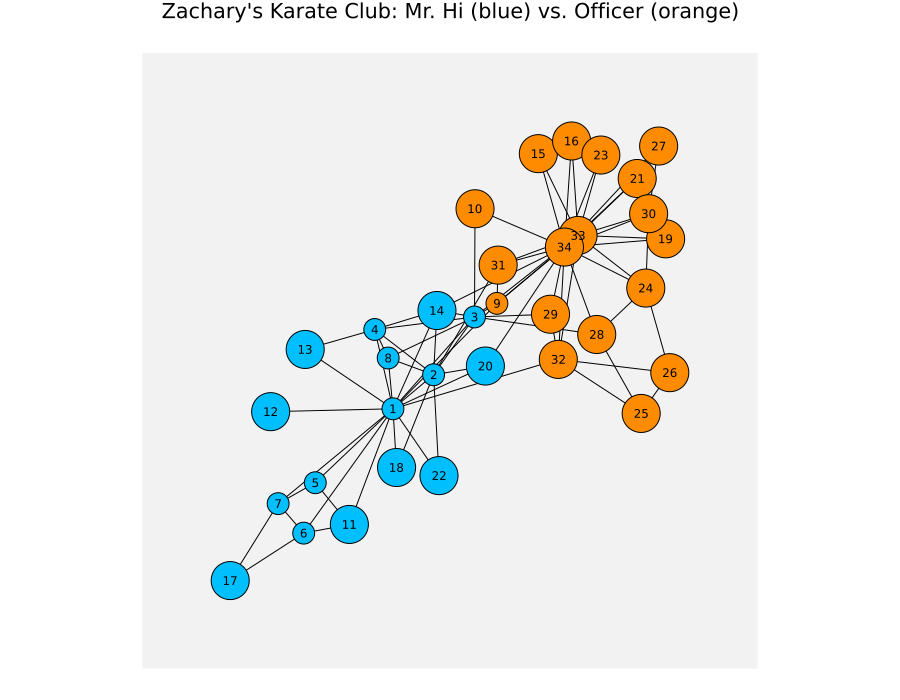

In [4]:
let
    g = smallgraph(:karate)
    node_colors = [labels[i] == 1 ? :deepskyblue : :darkorange for i in 1:N]
    node_names  = [string(i) for i in 1:N]

    p = graphplot(g;
        names = node_names,
        nodecolor = node_colors,
        nodesize  = 0.2,
        nodeshape = :circle,
        fontsize  = 8,
        curves    = false,
        method    = :spring,
        title     = "Zachary's Karate Club: Mr. Hi (blue) vs. Officer (orange)",
        bg = "gray95", background_color_outside = "white")

    plot(p; size = (900, 700),
        left_margin = 6Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 6Plots.mm, top_margin = 6Plots.mm)
end

### Visualize $\mathbf{A}$ and $\mathbf{P}$ side by side
We render the binary adjacency $\mathbf{A}$ and the symmetric-normalized propagation $\mathbf{P}$ as two heatmaps with rows and columns ordered by node ID. Compared with the binary adjacency, the non-zero entries of $\mathbf{P}$ are continuous (the symmetric weights $1/\sqrt{\hat{d}_{i}\hat{d}_{j}}$), the diagonal is non-zero (self-loops), and the rows of high-degree nodes are visibly damped relative to those of low-degree nodes.

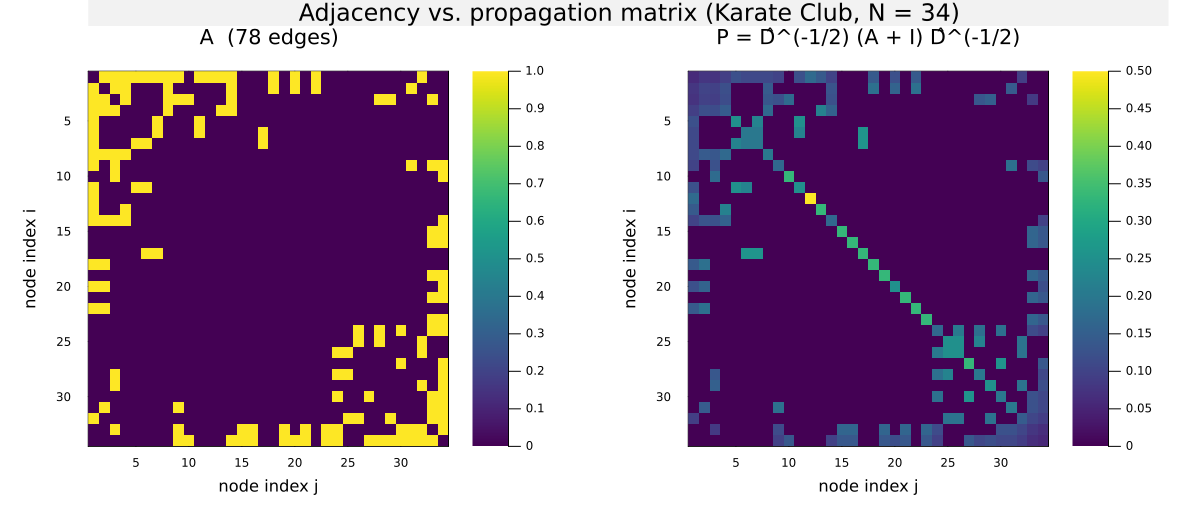

In [5]:
let
    p_A = heatmap(A;
        c = :viridis, clims = (0.0, 1.0),
        xlabel = "node index j", ylabel = "node index i",
        title  = "A  ($(Int(sum(A) ÷ 2)) edges)",
        yflip  = true,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box)

    p_P = heatmap(P;
        c = :viridis, clims = (0.0, maximum(P)),
        xlabel = "node index j", ylabel = "node index i",
        title  = "P = D̂^(-1/2) (A + I) D̂^(-1/2)",
        yflip  = true,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box)

    plot(p_A, p_P; layout = (1, 2), size = (1200, 520),
        plot_title = "Adjacency vs. propagation matrix (Karate Club, N = $(N))",
        left_margin = 10Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 6Plots.mm)
end

### Things to think about
* __What does the degree distribution tell you about the graph?__ Using only the `@info` output and the heatmaps: (a) Which two nodes are the hubs of the graph (highest degree), and which faction does each one belong to? Connect this back to the original ethnographic story. (b) The mean degree is roughly $4.6$; does this look like the kind of sparse social graph that the symmetric-normalized propagation was designed for, or like a near-complete graph for which the normalization barely matters?
* __Why does the spectral radius of $\mathbf{P}$ matter?__ Using only the eigenvalue output: (a) The largest eigenvalue is exactly $1$. What does that tell you about how the magnitude of $\mathbf{P}^{L}\mathbf{x}$ behaves as $L$ grows for a generic vector $\mathbf{x}$, compared to the un-normalized propagation $\hat{\mathbf{A}}^{L}\mathbf{x}$? (b) The smallest eigenvalue is close to but greater than $-1$. Connect this to the claim that "$\mathbf{P}$ keeps activations on a stable scale across layers" rather than amplifying or attenuating them exponentially.

___

## Task 2: GCN forward pass with random weights at increasing depth
In this task, we initialize the input feature matrix $\mathbf{X} = \mathbf{I}_{N}$ (one-hot node IDs), build $L$ GCN layers with Glorot-uniform random weights, run a single forward pass, and PCA-project the resulting $\mathbf{H}^{(L)}$ to two dimensions. The hidden width is $d_{h} = $ `d_hidden` at every layer, and the activation is ReLU.

> __What are we expecting to see?__
>
> At $L = 1$, each row of $\mathbf{H}^{(1)} = \mathrm{ReLU}(\mathbf{P}\mathbf{X}\mathbf{W}^{(0)})$ is a (rectified) linear combination of the rows of $\mathbf{P}$ associated with that node and its immediate neighbors, projected through a random $\mathbf{W}^{(0)}$. Since the projection is random, the 2D PCA of $\mathbf{H}^{(1)}$ should look mostly like noise with some hubs visibly separated by their large self-weights. At $L = 2$, each row depends on the 2-hop neighborhood of the corresponding node, and the two communities of the Karate Club start to become visibly separate in PCA space because most of the within-community edges are concentrated within a 2-hop ball of each node. At $L = 3$, the separation is sharper still.
>
> The point is that this happens with __random untrained weights__: the structural information content of the graph alone, propagated through $\mathbf{P}$, is enough to recover the community split.

The code block below stores the per-depth embedding matrices in `embeddings::Dict{Int64, Matrix{Float64}}` and the per-depth 2D PCA projections in `projections::Dict{Int64, Matrix{Float64}}`.

In [6]:
embeddings, projections = let
    Random.seed!(SEED)

    X = Matrix{Float64}(I, N, d_in)        # one-hot node IDs

    # Build the deepest stack we will need (max(DEPTHS_VIS)) and reuse its
    # prefixes for the shallower depths. Layer 1 maps d_in -> d_hidden;
    # subsequent layers map d_hidden -> d_hidden.
    L_max = maximum(DEPTHS_VIS)
    layers = Vector{MyGCNLayer}(undef, L_max)
    layers[1] = build(MyGCNLayer; d_in = d_in, d_out = d_hidden, activation = relu)
    for ℓ in 2:L_max
        layers[ℓ] = build(MyGCNLayer; d_in = d_hidden, d_out = d_hidden, activation = relu)
    end

    embeddings  = Dict{Int64, Matrix{Float64}}()
    projections = Dict{Int64, Matrix{Float64}}()
    for L in DEPTHS_VIS
        H = gcn_stack_forward(layers[1:L], P, X)
        embeddings[L]  = H
        projections[L] = pca_2d(H)
    end
    @info "Forward pass complete" depths=DEPTHS_VIS hidden=d_hidden
    (embeddings, projections)
end;

┌ Info: Forward pass complete
│   depths = [1, 2, 3]
│   hidden = 8
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-15/L15c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y126sZmlsZQ==.jl:23


### Visualize the 2D PCA projections
For each depth $L\in$ `DEPTHS_VIS` we plot the rows of $\mathbf{H}^{(L)}$ in their top-2 principal components. Points are colored by the original Zachary community label: blue for Mr. Hi's faction, orange for the Officer's faction. With well-mixed input features and random weights, the depth-1 plot should look near-random, while the depth-2 and depth-3 plots should already separate the two factions.

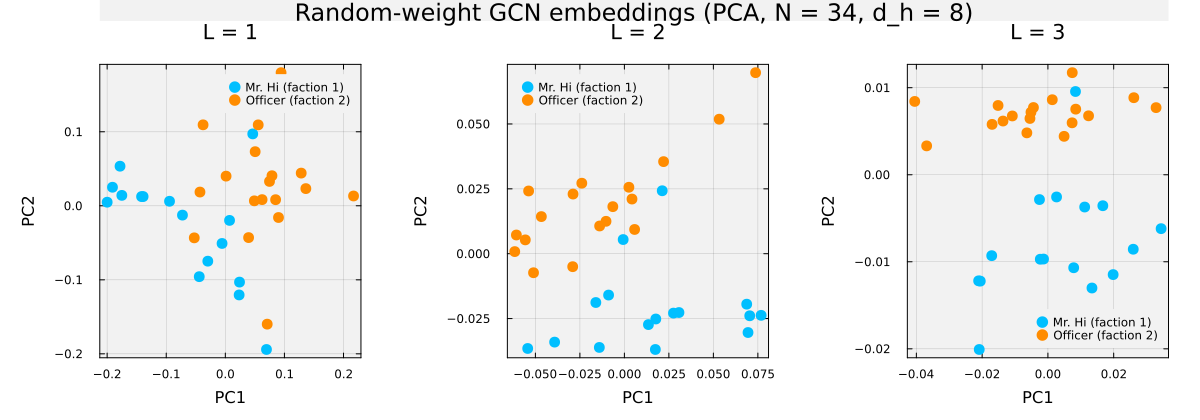

In [7]:
let
    subplots = Plots.Plot[]

    for L in DEPTHS_VIS
        Y = projections[L]
        # Split rows by community label so we can use two distinct colors and a legend.
        idx1 = findall(==(1), labels)
        idx2 = findall(==(2), labels)

        sp = scatter(Y[idx1, 1], Y[idx1, 2];
            ms = 6, msw = 0, c = :deepskyblue,
            label = "Mr. Hi (faction 1)",
            xlabel = "PC1", ylabel = "PC2",
            title  = "L = $(L)",
            bg = "gray95", background_color_outside = "white",
            framestyle = :box, fg_legend = :transparent)
        scatter!(sp, Y[idx2, 1], Y[idx2, 2];
            ms = 6, msw = 0, c = :darkorange,
            label = "Officer (faction 2)")
        push!(subplots, sp)
    end

    plot(subplots...; layout = (1, length(DEPTHS_VIS)), size = (1200, 420),
        plot_title = "Random-weight GCN embeddings (PCA, N = $(N), d_h = $(d_hidden))",
        left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 6Plots.mm)
end

### Things to think about
* __Where does the community separation come from at $L = 2$?__ Using only the PCA panels: (a) The weights $\mathbf{W}^{(\ell)}$ are random, so they cannot encode any community-specific signal on their own. What is it about $\mathbf{P}^{2}\mathbf{X}$ that lets a random projection still separate the two factions? Hint: think about which entries of $\mathbf{P}^{2}$ are large. (b) If you re-ran the forward pass with a different random seed, would the absolute positions of the points in the PCA plot change, and would the qualitative separation of the two factions change?

___

## Task 3: Oversmoothing as the depth grows
In this task, we sweep the depth $L\in$ `DEPTHS_SWEEP` and track the mean off-diagonal pairwise cosine similarity between rows of $\mathbf{H}^{(L)}$. Each time we apply $\mathbf{P}$, every node's feature vector becomes a (degree-weighted) average of its neighborhood, so deeper stacks pull node embeddings toward each other. Past some depth, every row of $\mathbf{H}^{(L)}$ is essentially a multiple of the same vector (the dominant eigenvector of $\mathbf{P}$, projected through the stacked random weight matrices), and the cosine similarity between any pair of rows approaches one.

> __What do we expect?__
>
> At small $L$ (say $L\in\{1, 2, 3\}$), the mean pairwise cosine similarity is moderate: nodes in the same community are similar, nodes in different communities are not. As $L$ grows past about $L = 5$ on this graph, the dominant eigenvalue of $\mathbf{P}$ (which is $1$) starts to dominate the propagation, and every row of $\mathbf{H}^{(L)}$ is increasingly aligned with the dominant eigenvector. By $L = 20$ the mean cosine similarity is close to one and the embeddings carry essentially no community information.

The code block below stores the sweep in `sweep_L::DataFrame`.

In [8]:
sweep_L = let
    Random.seed!(SEED + 1)

    X = Matrix{Float64}(I, N, d_in)

    L_max = maximum(DEPTHS_SWEEP)
    layers = Vector{MyGCNLayer}(undef, L_max)
    layers[1] = build(MyGCNLayer; d_in = d_in, d_out = d_hidden, activation = relu)
    for ℓ in 2:L_max
        layers[ℓ] = build(MyGCNLayer; d_in = d_hidden, d_out = d_hidden, activation = relu)
    end

    df = DataFrame(L = Int[], cos_sim_mean = Float64[], cos_sim_std = Float64[])
    for L in DEPTHS_SWEEP
        H = gcn_stack_forward(layers[1:L], P, X)
        S = pairwise_cosine_similarity(H)
        # Off-diagonal entries only (i ≠ j). Symmetric, so take upper triangle.
        offdiag = [S[i, j] for i in 1:N for j in (i + 1):N]
        push!(df, (L, mean(offdiag), std(offdiag)))
    end

    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

 ------- -------------- -------------
      L   cos_sim_mean   cos_sim_std 
  Int64        Float64       Float64 
 ------- -------------- -------------
      1         0.4209        0.2624
      2         0.3042        0.3558
      3         0.5755        0.2513
      4         0.7531        0.1759
      5         0.9507       0.03914
      6         0.9493       0.04809
      8          0.977       0.02416
     10         0.9997     0.0002826
     14         0.9999     0.0001341
     20            1.0      6.098e-7
 ------- -------------- -------------


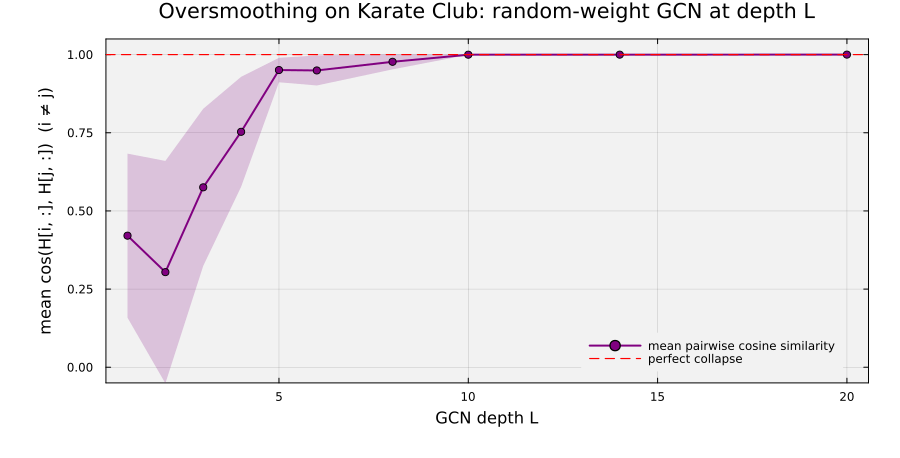

In [9]:
let
    p = plot(sweep_L.L, sweep_L.cos_sim_mean;
        ribbon = sweep_L.cos_sim_std, fillalpha = 0.2,
        label = "mean pairwise cosine similarity", lw = 2, marker = :circle, c = :purple,
        xlabel = "GCN depth L",
        ylabel = "mean cos(H[i, :], H[j, :])  (i ≠ j)",
        title  = "Oversmoothing on Karate Club: random-weight GCN at depth L",
        ylims  = (-0.05, 1.05),
        legend = :bottomright,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    hline!(p, [1.0]; c = :red, ls = :dash, lw = 1.2, label = "perfect collapse")

    plot(p; size = (900, 460),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __Why does the oversmoothing limit follow from the spectrum of $\mathbf{P}$?__ Using only the sweep table and the plot: (a) Roughly at what depth does the mean cosine similarity cross $0.95$ on this graph? (b) The propagation matrix has $\lambda_{1}(\mathbf{P}) = 1$ with multiplicity one and $|\lambda_{k}|< 1$ for all $k\geq 2$, so $\mathbf{P}^{L}$ converges to a rank-one matrix as $L\to\infty$. Connect this fact to the claim "every row of $\mathbf{H}^{(L)}$ approaches the same vector" and to the practical rule of thumb "use $L\in\{2, 3, 4\}$ in real applications."

___

## Summary
This notebook implemented the symmetric-normalized graph convolution of [Kipf and Welling (2017)](https://arxiv.org/abs/1609.02907) by hand on Zachary's Karate Club. The propagation matrix $\mathbf{P} = \hat{\mathbf{D}}^{-1/2}(\mathbf{A} + \mathbf{I})\hat{\mathbf{D}}^{-1/2}$ was a fixed function of the adjacency, and the per-layer weight matrices were Glorot-uniform random and never trained. Two diagnostics were enough to expose the qualitative behavior of the architecture: a 2D PCA scatter plot of the rows of $\mathbf{H}^{(L)}$, and the mean pairwise cosine similarity between rows of $\mathbf{H}^{(L)}$.

> __Key Takeaways:__
>
> * __The structure of the graph carries the signal even before training:__ At depth $L = 2$ on the Karate Club, a single forward pass through the symmetric-normalized propagation with random Glorot weights already separates the two factions in PCA space. The propagation matrix is the only object that knows about the graph; the random weights only project the propagated features into a lower-dimensional space.
> * __The largest eigenvalue of $\mathbf{P}$ is one and that is what makes the stack stable:__ The symmetric normalization is exactly the rescaling that fixes the spectral radius of $\hat{\mathbf{A}}$ at one, so layer activations stay on a stable scale across depth instead of blowing up or vanishing exponentially. This is the property that makes GCN trainable by ordinary backpropagation in real applications.
> * __Deep GCN stacks oversmooth:__ Each application of $\mathbf{P}$ averages a node's feature vector with its neighborhood, and $\mathbf{P}^{L}$ converges to a rank-one matrix as $L\to\infty$, so deep stacks pull every row of $\mathbf{H}^{(L)}$ toward the same vector. The depth at which the mean pairwise cosine similarity crosses any fixed threshold is graph-dependent (the relevant scale is the spectral gap $1 - |\lambda_{2}(\mathbf{P})|$), and is the reason the practical sweet spot for GCN depth is small (typically $L\in\{2, 3, 4\}$).

Taken together, the two sweeps show why GCN works as a feature extractor on graph-structured data, and why training is needed only to specialize the propagated features to a particular task. The L15d lab takes the next step by training a GraphSAGE-style network on the MUTAG molecular dataset with a graph-classification readout.
___